<a href="https://colab.research.google.com/github/Marcin19721205/WSBNeuronowe/blob/main/PROJEKT_SIECI_NEURONOWE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Grupa projektowa: Marcin Jabłoński / Marta Niebrzegowska

### Spis treści:
1. [Import bibliotek](#0)
2. [Zbiór danych Cifar](#1)
3. [Standaryzacja](#2)
4. [PCA - 2 komponenty](#3)
5. [PCA - 3 komponenty](#4)
6. [Zbiór danych MNIST](#5)
7. [Zbiór danych Cifar](#6)




### <a name='0'></a> Import bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

np.set_printoptions(precision=4, suppress=True, linewidth=150)


import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.decomposition import PCA

### <a name='0'></a> Zbiór danych Cifar

In [2]:
#wczytanie CIFAR10
(cifar10_X_train_raw, cifar10_y_train_raw), (cifar10_X_test_raw, cifar10_y_test_raw) = cifar10.load_data()

print("cifar10_X_train_raw:", cifar10_X_train_raw.shape)
print("cifar10_y_train_raw:", cifar10_y_train_raw.shape)
print("cifar10_X_test_raw:", cifar10_X_test_raw.shape)
print("cifar10_y_test_raw:", cifar10_y_test_raw.shape)

# spłaszczenie etyiet
cifar10_y_train = cifar10_y_train_raw.reshape(-1)
cifar10_y_test  = cifar10_y_test_raw.reshape(-1)


cifar10_X_train_raw: (50000, 32, 32, 3)
cifar10_y_train_raw: (50000, 1)
cifar10_X_test_raw: (10000, 32, 32, 3)
cifar10_y_test_raw: (10000, 1)


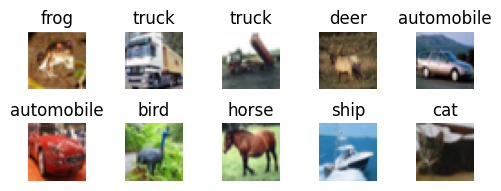

In [3]:
# szybki podgląd
cifar10_class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

plt.figure(figsize=(5, 2))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(cifar10_X_train_raw[i])
    plt.title(cifar10_class_names[cifar10_y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()


In [4]:
cifar10_y_test_raw[:5]

array([[3],
       [8],
       [8],
       [0],
       [6]], dtype=uint8)

Standaryzacja

In [5]:
# skalowanie + standaryzacja per-kanał (train)
cifar10_X_train_scaled = cifar10_X_train_raw.astype(np.float32) / 255.0
cifar10_X_test_scaled  = cifar10_X_test_raw.astype(np.float32) / 255.0

# mean/std po (N,H,W) osobno dla kanałów RGB
cifar10_mean_ch = cifar10_X_train_scaled.mean(axis=(0, 1, 2), keepdims=True)
cifar10_std_ch  = cifar10_X_train_scaled.std(axis=(0, 1, 2), keepdims=True) + 1e-7  # żeby nie dzielić przez 0

cifar10_X_train_std = (cifar10_X_train_scaled - cifar10_mean_ch) / cifar10_std_ch
cifar10_X_test_std  = (cifar10_X_test_scaled  - cifar10_mean_ch) / cifar10_std_ch

print("mean RGB:", cifar10_mean_ch.reshape(-1))
print("std  RGB:", cifar10_std_ch.reshape(-1))
print("train std shape:", cifar10_X_train_std.shape)


mean RGB: [0.4914 0.4822 0.4465]
std  RGB: [0.247  0.2435 0.2616]
train std shape: (50000, 32, 32, 3)


Augmentacja

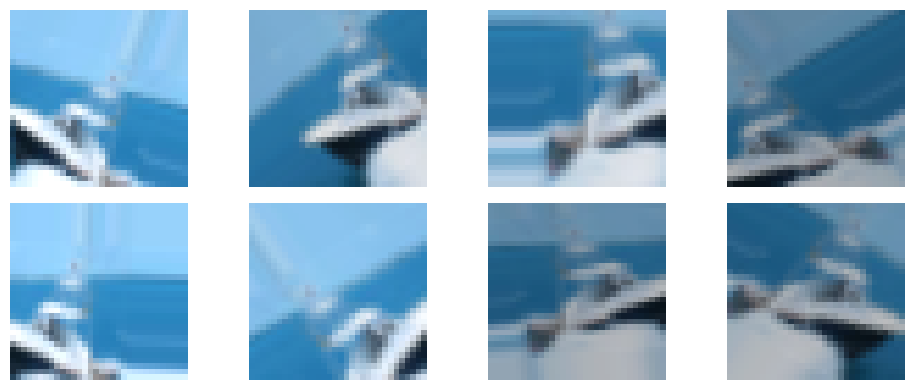

In [7]:
# augmentacja CIFAR10 + podgląd (pewna wersja: RAW uint8 + rescale)

# generator augmentacji
cifar10_datagen_aug = ImageDataGenerator(
    rescale=1.0/255.0,          # RAW 0..255 -> float 0..1
    width_shift_range=0.3,
    height_shift_range=0.3,
    rotation_range=45,
    brightness_range=[0.7, 1.3],  # mniej agresywnie
    zoom_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode="nearest"
)

# 3) iterator dla wybranego obrazu
cifar10_x0_raw = cifar10_X_train_raw[8]                 # (32,32,3) uint8
cifar10_it = cifar10_datagen_aug.flow(
    np.expand_dims(cifar10_x0_raw, axis=0),             # (1,32,32,3)
    batch_size=1,
    shuffle=False,
    seed=123
)

# 4) podgląd 8 augmentacji
plt.figure(figsize=(10, 4))
for i in range(8):
    x_aug = next(cifar10_it)[0]                         # (32,32,3) float w [0..1]
    plt.subplot(2, 4, i + 1)
    plt.imshow(np.clip(x_aug, 0.0, 1.0))
    plt.axis("off")

plt.tight_layout()
plt.show()


In [11]:
# Komórka 1 — spłaszczenie obrazów pod PCA (N, 32*32*3)
#
# SPYTAJ SIĘ PO CO
cifar10_X_train_flat = cifar10_X_train_std.reshape(cifar10_X_train_std.shape[0], -1)
cifar10_X_test_flat  = cifar10_X_test_std.reshape(cifar10_X_test_std.shape[0],  -1)

print("cifar10_X_train_flat:", cifar10_X_train_flat.shape)
print("cifar10_X_test_flat :", cifar10_X_test_flat.shape)


cifar10_X_train_flat: (50000, 3072)
cifar10_X_test_flat : (10000, 3072)


In [12]:
# Komórka 2 — PCA: kilka wariantów n_components + zapis do słownika (pod porównania)
from sklearn.decomposition import PCA

cifar10_pca_components_list = [64, 128, 256, 512]  # warianty do porównania
cifar10_pca_bundle = {}  # tu trzymamy: model PCA + transformacje + explained variance

for cifar10_pca_n in cifar10_pca_components_list:
    cifar10_pca_model = PCA(n_components=cifar10_pca_n, random_state=123)

    cifar10_X_train_pca = cifar10_pca_model.fit_transform(cifar10_X_train_flat)  # fit tylko na train
    cifar10_X_test_pca  = cifar10_pca_model.transform(cifar10_X_test_flat)

    cifar10_pca_bundle[cifar10_pca_n] = {
        "pca_model": cifar10_pca_model,
        "X_train_pca": cifar10_X_train_pca,
        "X_test_pca": cifar10_X_test_pca,
        "explained_var_sum": float(cifar10_pca_model.explained_variance_ratio_.sum()),
    }

    print(f"PCA={cifar10_pca_n}: X_train_pca={cifar10_X_train_pca.shape}, explained_sum={cifar10_pca_bundle[cifar10_pca_n]['explained_var_sum']:.4f}")


PCA=64: X_train_pca=(50000, 64), explained_sum=0.8646
PCA=128: X_train_pca=(50000, 128), explained_sum=0.9183
PCA=256: X_train_pca=(50000, 256), explained_sum=0.9583
PCA=512: X_train_pca=(50000, 512), explained_sum=0.9839


In [19]:
# Komórka — wykres wariancji PCA jak na Twoim screenie (bar + cumulative line) dla wybranego n_components

import numpy as np
import pandas as pd
import plotly.graph_objects as go

# wybierz wariant PCA (musi istnieć w cifar10_pca_bundle)
cifar10_pca_n_plot = 512

cifar10_pca_model_plot = cifar10_pca_bundle[cifar10_pca_n_plot]["pca_model"]
cifar10_ev_ratio = cifar10_pca_model_plot.explained_variance_ratio_
cifar10_ev_cum = np.cumsum(cifar10_ev_ratio)

cifar10_pca_var_df = pd.DataFrame({
    "component": np.arange(1, len(cifar10_ev_ratio) + 1),
    "explained_variance_ratio": cifar10_ev_ratio,
    "cumulative": cifar10_ev_cum
})

fig = go.Figure(data=[
    go.Bar(
        x=cifar10_pca_var_df["component"],
        y=cifar10_pca_var_df["explained_variance_ratio"],
        name="explained_variance_ratio"
    ),
    go.Scatter(
        x=cifar10_pca_var_df["component"],
        y=cifar10_pca_var_df["cumulative"],
        mode="lines+markers",
        name="cumulative",
        yaxis="y2"
    )
])

fig.update_layout(
    title=f"CIFAR10 — PCA variance (n_components={cifar10_pca_n_plot})",
    template="plotly_dark",
    width=950,
    height=550,
    xaxis=dict(title="component"),
    yaxis=dict(title="explained_variance_ratio"),
    yaxis2=dict(
        title="cumulative",
        overlaying="y",
        side="right",
        range=[0, 1.0]
    ),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

# jak chcesz podejrzeć tabelę jak na screenie:
cifar10_pca_var_df.head(10)


,component,explained_variance_ratio,cumulative
0,1,0.289052,0.289052
1,2,0.113032,0.402084
2,3,0.066913,0.468997
3,4,0.036853,0.505850
4,5,0.035499,0.541349
5,6,0.028226,0.569576
6,7,0.027250,0.596825
7,8,0.021772,0.618597
8,9,0.020747,0.639344
9,10,0.014457,0.653801


In [15]:
# Komórka — PCA do wizualizacji (2D i 3D) + sampling

import numpy as np
from sklearn.decomposition import PCA

cifar10_class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

# spłaszcz pod PCA
cifar10_X_train_flat = cifar10_X_train_std.reshape(cifar10_X_train_std.shape[0], -1)

# sampling do plotów (żeby Plotly nie umarł)
cifar10_viz_n = 5000
rng = np.random.default_rng(123)
cifar10_viz_idx = rng.choice(cifar10_X_train_flat.shape[0], size=cifar10_viz_n, replace=False)

cifar10_X_train_flat_viz = cifar10_X_train_flat[cifar10_viz_idx]
cifar10_y_train_viz = cifar10_y_train[cifar10_viz_idx]

# PCA 2D i 3D (tylko pod wykresy)
cifar10_pca_viz2_model = PCA(n_components=2, random_state=123)
cifar10_X_train_pca2_viz = cifar10_pca_viz2_model.fit_transform(cifar10_X_train_flat_viz)

cifar10_pca_viz3_model = PCA(n_components=3, random_state=123)
cifar10_X_train_pca3_viz = cifar10_pca_viz3_model.fit_transform(cifar10_X_train_flat_viz)

print("PCA2 explained_sum:", float(cifar10_pca_viz2_model.explained_variance_ratio_.sum()))
print("PCA3 explained_sum:", float(cifar10_pca_viz3_model.explained_variance_ratio_.sum()))


PCA2 explained_sum: 0.39838677644729614
PCA3 explained_sum: 0.466023713350296


In [16]:
# Komórka — PCA 2D scatter (Plotly)

import pandas as pd
import plotly.express as px

cifar10_pca2_df = pd.DataFrame({
    "pca_1": cifar10_X_train_pca2_viz[:, 0],
    "pca_2": cifar10_X_train_pca2_viz[:, 1],
    "class_id": cifar10_y_train_viz
})
cifar10_pca2_df["class_name"] = cifar10_pca2_df["class_id"].map(lambda k: cifar10_class_names[int(k)])

fig = px.scatter(
    cifar10_pca2_df,
    x="pca_1", y="pca_2",
    color="class_name",
    opacity=0.55,
    template="plotly_dark",
    width=1000, height=600,
    title="CIFAR10 — PCA 2D (sample)"
)
fig.show()


In [17]:
# Komórka — PCA 3D scatter (Plotly)

cifar10_pca3_df = pd.DataFrame({
    "pca_1": cifar10_X_train_pca3_viz[:, 0],
    "pca_2": cifar10_X_train_pca3_viz[:, 1],
    "pca_3": cifar10_X_train_pca3_viz[:, 2],
    "class_id": cifar10_y_train_viz
})
cifar10_pca3_df["class_name"] = cifar10_pca3_df["class_id"].map(lambda k: cifar10_class_names[int(k)])

fig = px.scatter_3d(
    cifar10_pca3_df,
    x="pca_1", y="pca_2", z="pca_3",
    color="class_name",
    opacity=0.60,
    template="plotly_dark",
    width=1000, height=700,
    title="CIFAR10 — PCA 3D (sample)"
)
fig.show()


In [ ]:
X_train = X_train / 255.
X_test = X_test / 255.
X_train.shape

(50000, 32, 32, 3)

Wypłaszczenie obrazów

In [ ]:
X_train = X_train.reshape(-1, 32 * 32 * 3)
X_train.shape

(5000, 3072)

In [ ]:
X_train[:5]

array([[0.2314, 0.2431, 0.2471, ..., 0.4824, 0.3608, 0.2824],
       [0.6039, 0.6941, 0.7333, ..., 0.5608, 0.5216, 0.5647],
       [1.    , 1.    , 1.    , ..., 0.3137, 0.3373, 0.3294],
       [0.1098, 0.098 , 0.0392, ..., 0.2824, 0.2549, 0.1804],
       [0.6667, 0.7059, 0.7765, ..., 0.2863, 0.302 , 0.3137]])

PCA - 3 komponenty

In [ ]:
pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train)
X_train_pca[:5]

array([[ -6.5023,   2.5505,   1.5772],
       [  0.8709,  -0.8715,   6.2163],
       [  8.111 , -11.1948,  -2.6912],
       [-10.3522,  -0.2394,   1.2522],
       [ -2.4619,  -4.8347,   1.2479]])

Wyjaśniona wariancja

In [ ]:
results = pd.DataFrame(data={'explained_variance_ratio': pca.explained_variance_ratio_})
results['cumulative'] = results['explained_variance_ratio'].cumsum()
results['component'] = results.index + 1
results

,explained_variance_ratio,cumulative,component
0,0.291944,0.291944,1
1,0.112451,0.404395,2
2,0.066359,0.470754,3


In [ ]:
fig = go.Figure(data=[go.Bar(x=results['component'], y=results['explained_variance_ratio'], name='explained_variance_ratio'),
                      go.Scatter(x=results['component'], y=results['cumulative'], name='cumulative')],
                layout=go.Layout(title='PCA - 3 components', width=950, template='plotly_dark'))
fig.show()

In [ ]:
X_train_pca_df = pd.DataFrame(np.c_[X_train_pca, y_train], columns=['pca_1', 'pca_2', 'pca_3', 'class'])
X_train_pca_df['name'] = X_train_pca_df['class'].map(targets)
X_train_pca_df['class'] = X_train_pca_df['class'].astype('str')
X_train_pca_df.head()

,pca_1,pca_2,pca_3,class,name
0,-6.502318,2.550480,1.577222,6.0,frog
1,0.870890,-0.871500,6.216318,9.0,truck
2,8.111013,-11.194790,-2.691169,9.0,truck
3,-10.352160,-0.239424,1.252191,4.0,deer
4,-2.461939,-4.834697,1.247860,1.0,automobile


Wizualizacja 3D głównych komponentów

In [ ]:
px.scatter_3d(X_train_pca_df, x='pca_1', y='pca_2', z='pca_3', color='name',
              symbol='name', opacity=0.7, size_max=10, width=950, height=700,
              title='PCA - CIFAR dataset', template='plotly_dark')

PCA - 0.95% wariancji

In [ ]:
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train)
X_train_pca[:5]

array([[ -6.5023,   2.5505,   1.5772, ...,  -0.2103,   0.0938,  -0.029 ],
       [  0.8709,  -0.8715,   6.2163, ...,  -0.3181,   0.2744,  -0.6623],
       [  8.111 , -11.1948,  -2.6912, ...,  -0.2744,   0.2524,   0.0605],
       [-10.3522,  -0.2394,   1.2522, ...,   0.0044,   0.0575,   0.0231],
       [ -2.4619,  -4.8347,   1.2479, ...,   0.0938,   0.23  ,  -0.0335]])

In [ ]:
pca.n_components_

203

In [ ]:
pca.explained_variance_ratio_

array([0.2919, 0.1125, 0.0664, 0.0371, 0.0354, 0.0288, 0.0265, 0.0219, 0.0211, 0.0145, 0.0135, 0.0105, 0.0105, 0.0101, 0.0091, 0.0085, 0.0075,
       0.0071, 0.0067, 0.0066, 0.0062, 0.0058, 0.0051, 0.0049, 0.0048, 0.0047, 0.0046, 0.0045, 0.0041, 0.004 , 0.0037, 0.0034, 0.0032, 0.0032,
       0.0031, 0.003 , 0.0027, 0.0026, 0.0025, 0.0025, 0.0025, 0.0024, 0.0023, 0.0022, 0.0021, 0.0021, 0.0019, 0.0019, 0.0018, 0.0018, 0.0018,
       0.0017, 0.0017, 0.0017, 0.0017, 0.0016, 0.0016, 0.0016, 0.0015, 0.0015, 0.0015, 0.0014, 0.0014, 0.0014, 0.0014, 0.0013, 0.0013, 0.0013,
       0.0012, 0.0012, 0.0012, 0.0012, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.001 , 0.001 , 0.001 , 0.001 , 0.001 , 0.001 , 0.001 ,
       0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0009, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0008, 0.0007, 0.0007,
       0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0007, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006, 0.0006,

Wariancja wyjaśniona

In [ ]:
results = pd.DataFrame(data={'explained_variance_ratio': pca.explained_variance_ratio_})
results['cumulative'] = results['explained_variance_ratio'].cumsum()
results['component'] = results.index + 1
results.head()

,explained_variance_ratio,cumulative,component
0,0.291944,0.291944,1
1,0.112451,0.404395,2
2,0.066359,0.470754,3
3,0.037136,0.507891,4
4,0.035443,0.543334,5


In [ ]:
fig = go.Figure(data=[go.Bar(x=results['component'], y=results['explained_variance_ratio'], name='explained_variance_ratio'),
                      go.Scatter(x=results['component'], y=results['cumulative'], name='cumulative')],
                layout=go.Layout(title=f'PCA - {pca.n_components_} components', width=950, template='plotly_dark'))
fig.show()